# Introduction to Quantum Computing
### A hands-on workshop with Qiskit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AngelGab3/Quantum-Computing/blob/main/Intro_to_Quantum_Computing.ipynb)

Welcome! This notebook is a self-contained, hands-on introduction to quantum computing: from bits to qubits, single- and multi-qubit gates, superposition, entanglement, interference, and two classic algorithms (Deutsch–Jozsa and Grover) — finishing with a look at noise on real hardware.


## How to use this notebook
- **Run the cells in order**, top to bottom (`Shift + Enter`, or *Runtime ▸ Run all*).
- Below each code block you'll see its output: a number, a drawn circuit, a histogram, or a Bloch sphere. **Read the explanation, run the cell, and compare** it with what's described.
- Quick visual guide: a **circuit** shows the program; a **histogram** shows how often each outcome occurred; the **Bloch sphere** shows the state of a qubit as an arrow.

# 1 · Setting up the environment
We install Qiskit and its plotting/simulation utilities. The first run takes about a minute.

In [ ]:
# Install Qiskit and utilities
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator

print('Qiskit version:', qiskit.__version__)
sim = AerSimulator()   # our ideal simulator
print('Simulator ready.')

Qiskit version: 2.5.1
Simulator ready.


> If the `import` fails right after installing, restart the runtime and run the cells again.

# 2 · From bit to qubit

A classical **bit** is either 0 or 1. A **qubit** is described by a **state vector** with two amplitudes (complex numbers), one for |0⟩ and one for |1⟩:

$$|\psi\rangle = \alpha\,|0\rangle + \beta\,|1\rangle, \qquad |\alpha|^2 + |\beta|^2 = 1$$

When we **measure**, we get 0 with probability $|\alpha|^2$ and 1 with probability $|\beta|^2$ (the **Born rule**). A freshly created qubit starts in |0⟩, i.e. $\alpha=1,\ \beta=0$.

In [ ]:
qc = QuantumCircuit(1)          # 1 qubit, no gates yet
state = Statevector(qc)
print('Amplitudes [alpha, beta]:', np.round(state.data, 3))
print('Probabilities:', state.probabilities_dict())

Amplitudes [alpha, beta]: [1.+0.j 0.+0.j]
Probabilities: {np.str_('0'): np.float64(1.0)}


The same information, written in **Dirac notation** (ket):

In [ ]:
state.draw('latex')

<IPython.core.display.Latex object>

Expected output: amplitudes `[1, 0]`, probability `{'0': 1.0}`, and the ket $|0\rangle$. All consistent: a qubit in |0⟩ always measures 0.

# 3 · Single-qubit gates

A **gate** is an operation that transforms the qubit's state. Mathematically it's a **unitary matrix** (2×2 for a single qubit); geometrically, a **rotation** of the arrow on the Bloch sphere. "Unitary" means it's **reversible** and preserves total probability.

To build good intuition, we'll look at **each gate in three ways at once**:
1. its **matrix** and its effect on |0⟩ and |1⟩,
2. its **symbol** as it appears in a circuit, and
3. its **Bloch sphere before and after**, so you can *see* the rotation.

First we define a helper function that shows all three. (Just run it; we'll reuse it for every gate.)

In [ ]:
from IPython.display import display

def matrix_of(qc):
    'Matrix (operator) implemented by the circuit, rounded.'
    return np.round(Operator(qc).data, 3)

def show_gate(title, apply_gate, initial='0'):
    '''Shows the matrix + its effect, the symbol in the circuit, and the Bloch
       sphere of the initial state and the result (so you can SEE the rotation).'''
    qc = QuantumCircuit(1)
    apply_gate(qc)
    print('===', title, '===')
    print('Matrix:'); print(matrix_of(qc))
    for lbl in ['0', '1']:
        r = Statevector.from_label(lbl).evolve(qc).to_dict()
        print(f'  |{lbl}>  ->  {r}')

    print('\nSymbol in the circuit:')
    fig = qc.draw('mpl'); display(fig); plt.close(fig)

    before = Statevector.from_label(initial)
    after = before.evolve(qc)
    print(f'Bloch sphere —  BEFORE: |{initial}>   (top)    AFTER  (bottom):')
    for st in (before, after):
        fig = plot_bloch_multivector(st); display(fig); plt.close(fig)

### 3.1 · The X gate — the quantum "NOT"
Swaps |0⟩ and |1⟩; on the sphere, it's a **180° rotation around the X axis** (the arrow flips from pointing up to pointing down).
$$X = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$$

=== X (NOT) ===
Matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
  |0>  ->  {np.str_('1'): np.complex128(1+0j)}
  |1>  ->  {np.str_('0'): np.complex128(1+0j)}

Symbol in the circuit:


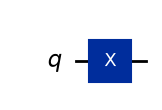

Bloch sphere —  BEFORE: |0>   (top)    AFTER  (bottom):


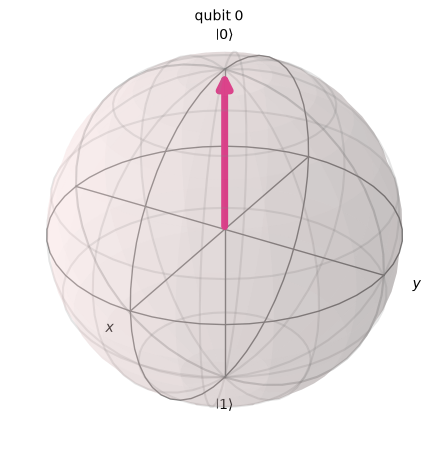

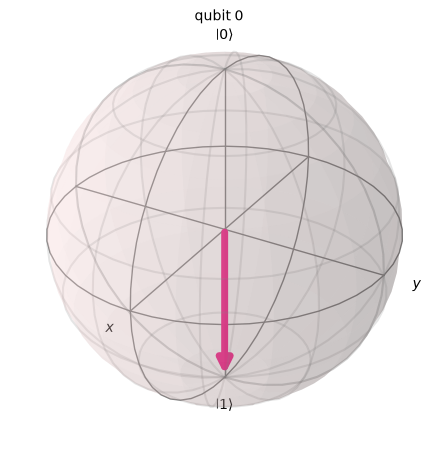

In [ ]:
show_gate('X (NOT)', lambda c: c.x(0), initial='0')

You'll see the **X** symbol in the circuit, and the arrow jump from |0⟩ (top) to |1⟩ (bottom).

### 3.2 · The Z gate — the phase flip
Leaves |0⟩ unchanged and puts a minus sign on |1⟩. On |0⟩ or |1⟩ **nothing visibly changes** on the sphere; its effect shows up on the equator. That's why here we start from $|+\rangle$: Z rotates it 180° to $|-\rangle$ (from one side of the equator to the opposite side).
$$Z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$$

=== Z (phase flip) ===
Matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  |0>  ->  {np.str_('0'): np.complex128(1+0j)}
  |1>  ->  {np.str_('1'): np.complex128(-1+0j)}

Symbol in the circuit:


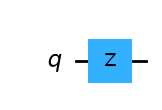

Bloch sphere —  BEFORE: |+>   (top)    AFTER  (bottom):


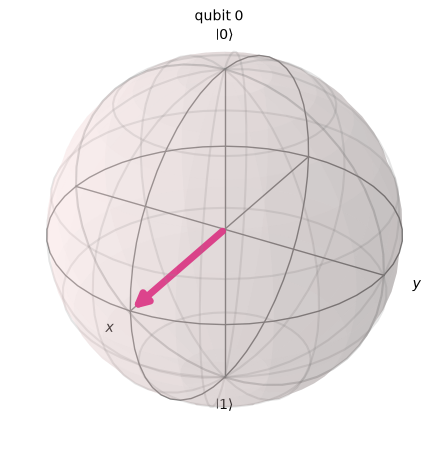

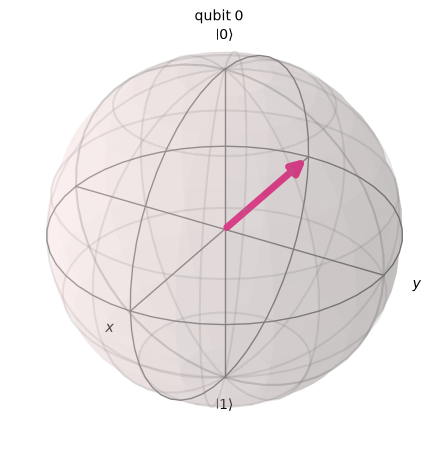

In [ ]:
show_gate('Z (phase flip)', lambda c: c.z(0), initial='+')

In the circuit you'll see the **Z** symbol; on the sphere, the arrow on the equator flips from |+⟩ to |−⟩.

### 3.3 · The H (Hadamard) gate — creates superposition
The star of the show: it turns definite states into **superpositions**. On the sphere it takes the arrow from the |0⟩ pole **all the way to the equator** ($|+\rangle$): half and half.
$$H = \tfrac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}$$

=== H (Hadamard) ===
Matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
  |0>  ->  {np.str_('0'): np.complex128(0.7071067811865475+0j), np.str_('1'): np.complex128(0.7071067811865475+0j)}
  |1>  ->  {np.str_('0'): np.complex128(0.7071067811865475+0j), np.str_('1'): np.complex128(-0.7071067811865475+0j)}

Symbol in the circuit:


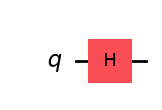

Bloch sphere —  BEFORE: |0>   (top)    AFTER  (bottom):


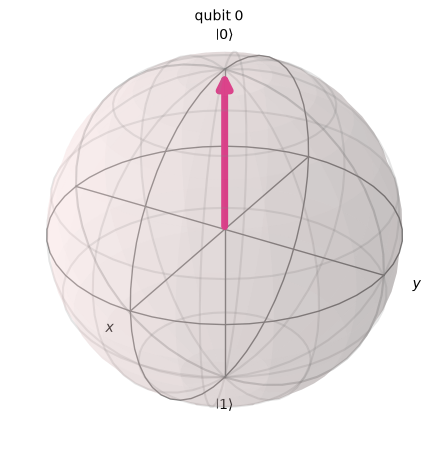

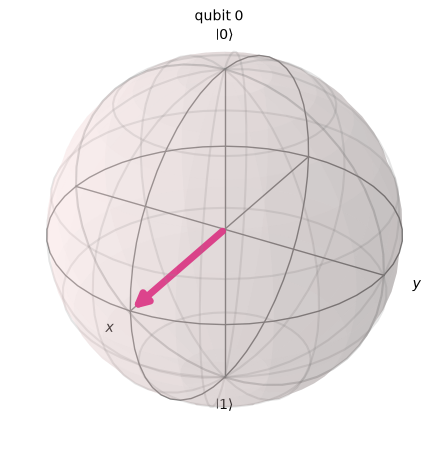

In [ ]:
show_gate('H (Hadamard)', lambda c: c.h(0), initial='0')

Each amplitude equals $1/\sqrt2 \approx 0.707$, and on the sphere the arrow ends up **horizontal**: neither up nor down, exactly in superposition.

### 3.4 · A few other useful ones: S and the free-angle rotations
- **S** (and **T**): "half" phase rotations of $90°$ (and $45°$) on the equator. Here S takes $|+\rangle$ to $|+i\rangle$ (a quarter turn around the equator).
- **Rotations** `rx(θ)`, `ry(θ)`, `rz(θ)`: rotate the qubit by an angle $θ$ *of your choice*. With these you can move the arrow to **any** point on the sphere. Try changing the angle and see what happens.

=== S (90-degree phase) ===
Matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
  |0>  ->  {np.str_('0'): np.complex128(1+0j)}
  |1>  ->  {np.str_('1'): np.complex128(1j)}

Symbol in the circuit:


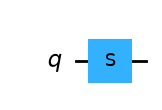

Bloch sphere —  BEFORE: |+>   (top)    AFTER  (bottom):


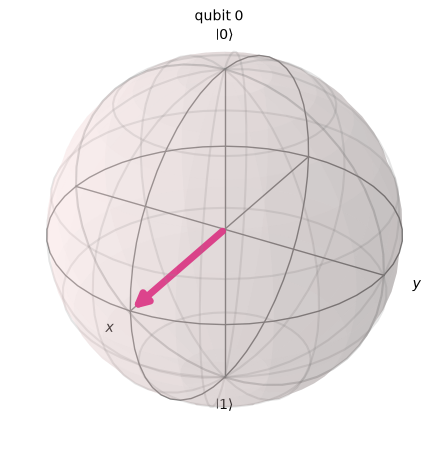

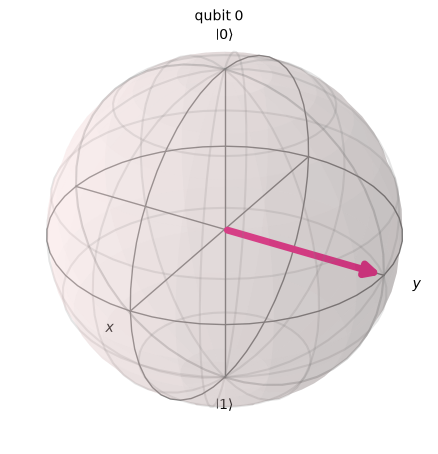

In [ ]:
show_gate('S (90-degree phase)', lambda c: c.s(0), initial='+')

=== RY(60 degrees) — free rotation ===
Matrix:
[[ 0.866+0.j -0.5  +0.j]
 [ 0.5  +0.j  0.866+0.j]]
  |0>  ->  {np.str_('0'): np.complex128(0.8660254037844387+0j), np.str_('1'): np.complex128(0.49999999999999994+0j)}
  |1>  ->  {np.str_('0'): np.complex128(-0.49999999999999994+0j), np.str_('1'): np.complex128(0.8660254037844387+0j)}

Symbol in the circuit:


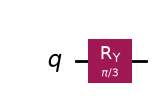

Bloch sphere —  BEFORE: |0>   (top)    AFTER  (bottom):


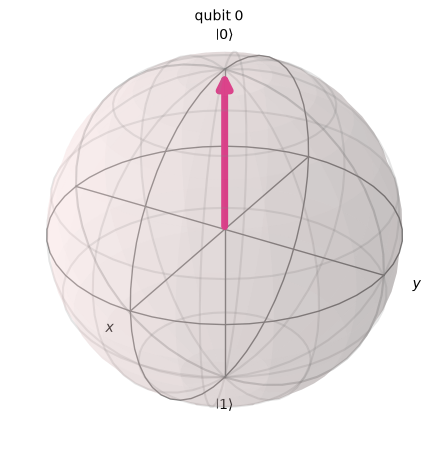

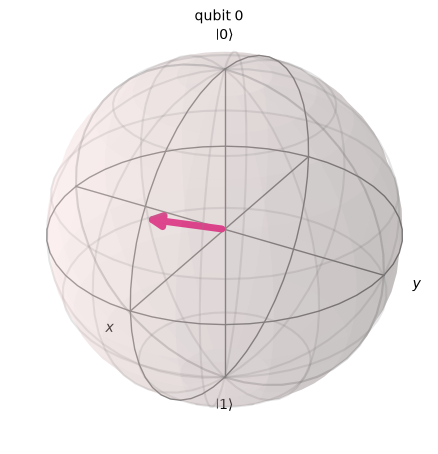

In [ ]:
show_gate('RY(60 degrees) — free rotation', lambda c: c.ry(np.pi/3, 0), initial='0')

In `RY(60°)` the arrow tilts *partway*: the probabilities of 0 and 1 change continuously. **That fine-grained control is something a classical bit doesn't have.**

### Summary of single-qubit gates
| Gate | What it does | On the Bloch sphere | In Qiskit |
|---|---|---|---|
| X | NOT: swaps \|0⟩ and \|1⟩ | 180° rotation, X axis | `qc.x(0)` |
| Z | puts a − sign on \|1⟩ (phase) | 180° rotation, Z axis | `qc.z(0)` |
| H | creates superposition | pole → equator | `qc.h(0)` |
| Y | NOT with an imaginary phase | 180° rotation, Y axis | `qc.y(0)` |
| S, T | phase rotations (90°, 45°) | rotation around the equator | `qc.s(0)`, `qc.t(0)` |
| RX/RY/RZ | rotation by a chosen angle | rotation by θ, your choice | `qc.rx(θ,0)` |

# 4 · Superposition and measurement

Let's put H into practice. We add a **measurement** to read the qubit and store it in a classical bit. When measured, the superposition **collapses** to 0 or 1, at random, following the Born probabilities.

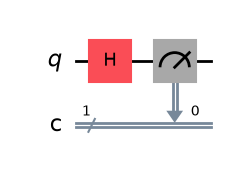

In [ ]:
qc = QuantumCircuit(1, 1)     # 1 qubit + 1 classical bit
qc.h(0)                       # superposition
qc.measure(0, 0)              # measure the qubit -> bit
qc.draw('mpl')

The result of **one** measurement is random; the 50/50 split **emerges when you repeat it**. We run the circuit many times (each repetition is a *shot*) and count:

{'0': 507, '1': 517}


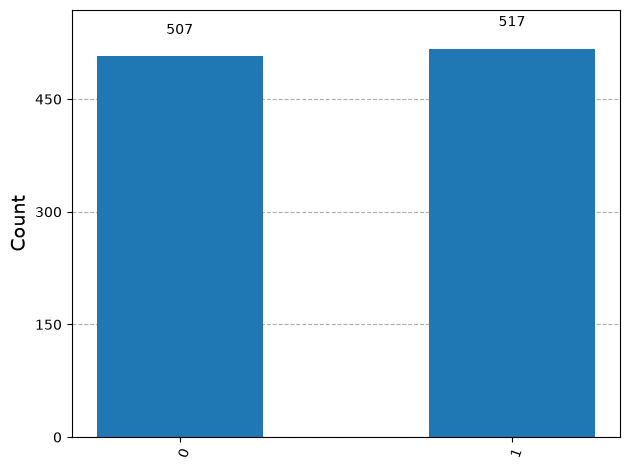

In [ ]:
counts = sim.run(qc, shots=1024).result().get_counts()
print(counts)
plot_histogram(counts)

With few shots the split is uneven; with many it approaches the 50/50 predicted by theory:

In [ ]:
for s in [1, 10, 100, 1024]:
    q = QuantumCircuit(1, 1); q.h(0); q.measure(0, 0)
    print(f'shots = {s:>4}  ->  {sim.run(q, shots=s).result().get_counts()}')

shots =    1  ->  {'0': 1}
shots =   10  ->  {'1': 7, '0': 3}
shots =  100  ->  {'1': 50, '0': 50}
shots = 1024  ->  {'0': 499, '1': 525}


# 5 · Multi-qubit gates

With several qubits come gates that **connect** them to each other. The most important is **CNOT** (or CX). But first, a detail that trips everyone up:

### 5.1 · Qubit ordering in Qiskit (important!)
Qiskit writes states **right to left**: in a string like `'10'`, the **rightmost bit is qubit 0** and the leftmost is qubit 1. In other words, `'10'` means $q_1=1,\ q_0=0$. Keep this in mind when reading histograms.

In [ ]:
# Demonstration: set ONLY qubit 0 to 1 and see how it's labeled
q = QuantumCircuit(2, 2)
q.x(0)                     # flip qubit 0
q.measure([0,1],[0,1])
print(sim.run(q, shots=100).result().get_counts())   # -> {'01': 100}

{'01': 100}


The result is `'01'`: the 1 is on the **right**, confirming that's where qubit 0 lives.

### 5.2 · CNOT (CX) — the linking gate
It has a **control** qubit and a **target** qubit. Rule: *if the control is 1, flip the target; if the control is 0, do nothing.* It's the "if" of the quantum world.

| control | target (before) | target (after) |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | **1** |
| 1 | 1 | **0** |

In [ ]:
qc = QuantumCircuit(2); qc.cx(0, 1)   # control=q0, target=q1
print('CNOT matrix (basis |q1 q0>):')
print(matrix_of(qc).real.astype(int))

CNOT matrix (basis |q1 q0>):
[[1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]


### 5.3 · Other multi-qubit gates
- **CZ**: applies a −1 phase only if *both* qubits are 1 (useful in algorithms).
- **SWAP**: swaps the state of two qubits.
- **Toffoli (CCX)**: double control — flips the target only if *both* controls are 1. It's a reversible AND; with it you can build any classical logic.

In [ ]:
for name, build in [
    ('CZ',      lambda c: c.cz(0,1)),
    ('SWAP',    lambda c: c.swap(0,1)),
]:
    qc = QuantumCircuit(2); build(qc)
    print(name, 'matrix:'); print(matrix_of(qc).real.astype(int)); print()

CZ matrix:
[[ 1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0 -1]]

SWAP matrix:
[[1 0 0 0]
 [0 0 1 0]
 [0 1 0 0]
 [0 0 0 1]]



### 5.4 · Their symbols in a circuit
Just like single-qubit gates, it's useful to recognize these at a glance. Here are their symbols:
- **CNOT**: a **dot** (control) connected by a line to a **⊕** (target).
- **CZ**: two connected **dots** (it's symmetric: it doesn't matter which is the control).
- **SWAP**: two connected **× marks**.
- **Toffoli (CCX)**: **two control dots** and a **⊕** target.

=== CNOT (CX): dot = control, cross = target ===


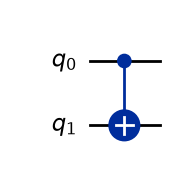

=== CZ: two dots ===


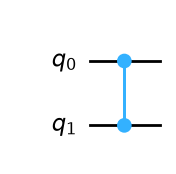

=== SWAP: two × marks ===


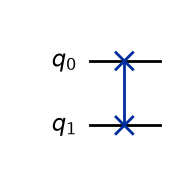

=== Toffoli (CCX): two controls + target ===


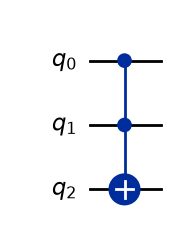

In [ ]:
def show_symbol(name, apply_gate, nq):
    qc = QuantumCircuit(nq); apply_gate(qc)
    print('===', name, '===')
    fig = qc.draw('mpl'); display(fig); plt.close(fig)

show_symbol('CNOT (CX): dot = control, cross = target', lambda c: c.cx(0, 1), 2)
show_symbol('CZ: two dots', lambda c: c.cz(0, 1), 2)
show_symbol('SWAP: two × marks', lambda c: c.swap(0, 1), 2)
show_symbol('Toffoli (CCX): two controls + target', lambda c: c.ccx(0, 1, 2), 3)

# 6 · Anatomy of a quantum circuit

A **circuit** is the recipe for the program. It reads **left to right** = the passage of time. Each horizontal line is a qubit; gates are placed on those lines in order. At the end, **measurement** dumps the qubits into classical bits (the double line).

Let's build one **step by step** and peek at the state after each gate.

In [ ]:
# Build the circuit and inspect the state after EACH step
qc = QuantumCircuit(2)
print(f'{"Start:":<10}', np.round(Statevector(qc).data, 3), ' = |00>')

qc.h(0)
print(f'{"After H:":<10}', np.round(Statevector(qc).data, 3), ' <- superposition')

qc.cx(0, 1)
print(f'{"After CX:":<10}', np.round(Statevector(qc).data, 3), ' <- entangled')

Start:     [1.+0.j 0.+0.j 0.+0.j 0.+0.j]  = |00>
After H:   [ 0.707+0.j  0.707+0.j  0.   +0.j -0.   +0.j]  <- superposition
After CX:  [0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]  <- entangled


Look at the vector: the four amplitudes are in the order `[|00>, |01>, |10>, |11>]`. After H, they're split between `|00>` and `|01>`; after CX, they end up on `|00>` and `|11>`. **The circuit transformed the state, gate by gate.**

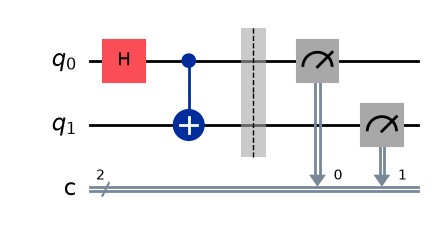

In [ ]:
# The same circuit, now with measurement and drawing
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.barrier()                 # visual separator (doesn't change the computation)
qc.measure([0, 1], [0, 1])
qc.draw('mpl')

Anatomy of what you see: two qubit lines (`q`), one bit line (`c`), the **H** on `q0`, the **CX** as a dot (control) connected to a ⊕ (target), the **barrier**, and the **measurements** at the end.

# 7 · Entanglement: the Bell state

The circuit above (H + CX) creates the **Bell state**, the textbook example of entanglement:
$$|\Phi^+\rangle = \tfrac{1}{\sqrt2}(|00\rangle + |11\rangle)$$
The two qubits become so linked that they **always agree**: we'll only ever see `00` and `11`, never `01` or `10`. Measuring one instantly tells you the other, even though neither was predetermined.

{'11': 500, '00': 524}


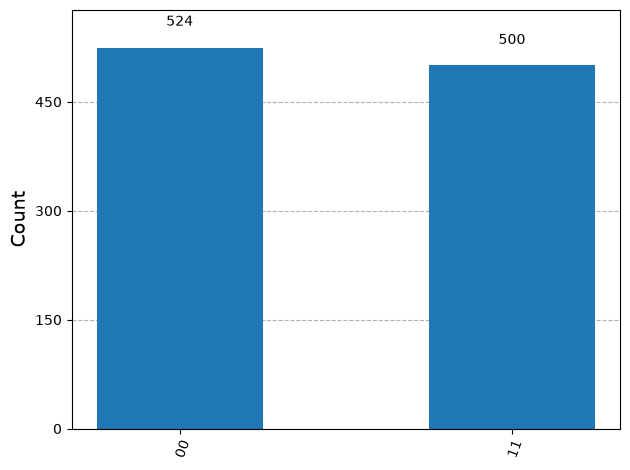

In [ ]:
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])
counts = sim.run(bell, shots=1024).result().get_counts()
print(counts)
plot_histogram(counts)

Expected: ~50% `00` and ~50% `11`, and **zero** `01`/`10`. That total absence is the signature of entanglement.

# 8 · Interference — the engine behind algorithms

Amplitudes can **add up or cancel out**, like waves. Minimal example: two H's in a row **cancel each other** (you're back to |0⟩). But if you insert a **Z** in between (changing a phase), now the other path is reinforced and you get |1⟩. The phase, invisible in a single measurement, **decides the outcome**.

In [ ]:
a = QuantumCircuit(1,1); a.h(0); a.h(0); a.measure(0,0)
print('H . H       ->', sim.run(a, shots=1024).result().get_counts(), ' (destructive interference)')

b = QuantumCircuit(1,1); b.h(0); b.z(0); b.h(0); b.measure(0,0)
print('H . Z . H   ->', sim.run(b, shots=1024).result().get_counts(), ' (constructive interference)')

H . H       -> {'0': 1024}  (destructive interference)
H . Z . H   -> {'1': 1024}  (constructive interference)


A quantum algorithm is, at its core, a circuit designed so that the amplitudes of the **wrong answers cancel out** while the **correct one is reinforced**. That's exactly what we'll see next.

# 9 · Quantum algorithms

Almost every algorithm follows the **same 3-step recipe**:
1. **Superposition**: apply H to every qubit to explore all possibilities at once.
2. **Oracle**: a part of the circuit that "marks" the correct answer(s) (usually with a phase).
3. **Interference**: a block that turns that invisible mark into a **high probability** of measuring the answer. Then we measure.

## 9.1 · Deutsch–Jozsa: one question, a single query

**The problem:** you're given a hidden function $f$ that is either **constant** (always the same output) or **balanced** (outputs 0 for half the inputs and 1 for the other half). Which is it?

- **Classically:** in the worst case you need to check more than half the inputs.
- **Quantumly:** with a **single** query to the oracle you can always solve it. The trick: if the final measurement is **all zeros**, it's constant; if you measure **anything else**, it's balanced.

In [ ]:
def deutsch_jozsa(oracle, n=2):
    qc = QuantumCircuit(n + 1, n)      # n input qubits + 1 ancilla
    qc.x(n); qc.h(n)                   # ancilla in |-> (for the "phase kickback")
    qc.h(range(n))                     # input in superposition
    qc.barrier()
    oracle(qc, n)                      # the hidden function
    qc.barrier()
    qc.h(range(n))                     # interference
    qc.measure(range(n), range(n))
    return qc

# CONSTANT oracle (f(x)=0): does nothing
def constant_oracle(qc, n): pass

# BALANCED oracle (f(x)=x0 XOR x1): two CNOTs to the ancilla
def balanced_oracle(qc, n):
    for i in range(n):
        qc.cx(i, n)

for name, oracle in [('constant', constant_oracle), ('balanced', balanced_oracle)]:
    qc = deutsch_jozsa(oracle, n=2)
    counts = sim.run(qc, shots=1024).result().get_counts()
    print(f'{name:>11}  ->  {counts}')

   constant  ->  {'00': 1024}
   balanced  ->  {'11': 1024}


Expected output: the **constant** oracle measures `'00'` (all zeros) and the **balanced** oracle measures `'11'` (not all zeros). A single run is enough to tell them apart: that's quantum advantage in its purest form.

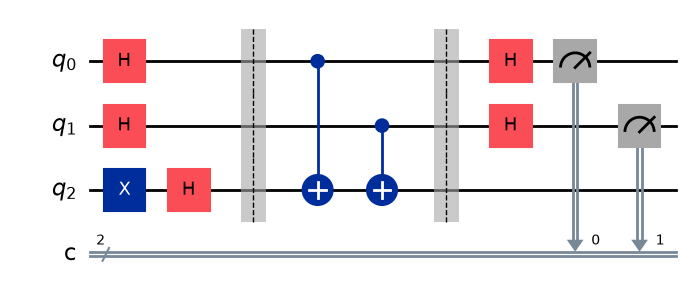

In [ ]:
# This is what the circuit looks like (balanced version)
deutsch_jozsa(balanced_oracle, n=2).draw('mpl')

## 9.2 · Grover: searching faster, step by step

**The problem:** among $N$ possibilities, one is "correct." Classically, on average you'd try $N/2$. Grover finds it in $\sim\sqrt{N}$ steps. We'll see it with 2 qubits ($N=4$), searching for the state `|11>`. We'll **inspect the amplitudes** at each stage.

In [ ]:
# STAGE 1 — uniform superposition: all 4 options with equal amplitude
g = QuantumCircuit(2)
g.h([0, 1])
print('Probabilities:', {str(k): round(float(v),3) for k,v in Statevector(g).probabilities_dict().items()})

Probabilities: {'00': 0.25, '01': 0.25, '10': 0.25, '11': 0.25}


Every state has probability 0.25. None stands out... yet.

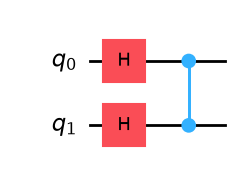

In [ ]:
# STAGE 2 — oracle: mark |11> with a minus sign (a phase)
g.cz(0, 1)
g.draw('mpl')   # we'll look at the state right after this

In [ ]:
sv = Statevector(g)
print('Amplitudes [|00>, |01>, |10>, |11>]:', np.round(sv.data, 3))
print('Probabilities:', {str(k): round(float(v),3) for k,v in sv.probabilities_dict().items()})

Amplitudes [|00>, |01>, |10>, |11>]: [ 0.5+0.j  0.5+0.j  0.5+0.j -0.5+0.j]
Probabilities: {'00': 0.25, '01': 0.25, '10': 0.25, '11': 0.25}


The **probabilities haven't changed** (still 0.25): the mark is only a **phase** (the − sign on `|11>`). It's invisible if you measured now. The next step turns it into something measurable.

In [ ]:
# STAGE 3 — diffuser: "inversion about the mean," amplifies the marked state
g.h([0, 1]); g.x([0, 1])
g.cz(0, 1)
g.x([0, 1]); g.h([0, 1])

sv = Statevector(g)
print('Probabilities:', {str(k): round(float(v),3) for k,v in sv.probabilities_dict().items()})

Probabilities: {'00': 0.0, '01': 0.0, '10': 0.0, '11': 1.0}


The probability of `|11>` jumped to ~1.0! The diffuser reflects every amplitude around their average: the marked one (which was pointing "down") grows, and the rest shrink. With 2 qubits, **a single** iteration is enough. Let's measure to confirm:

{'11': 1024}


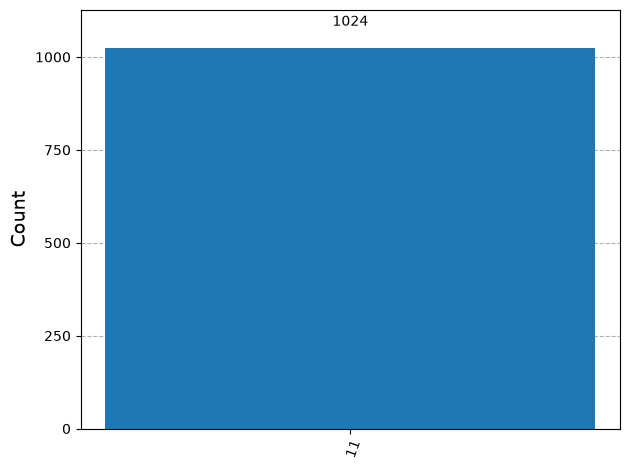

In [ ]:
g.measure_all()
counts = sim.run(g, shots=1024).result().get_counts()
print(counts)
plot_histogram(counts)

Almost 100% on `11`: interference amplified the correct answer and canceled out the rest. **That's the core mechanism behind most quantum algorithms.**

# 10 · Noise and real hardware

Real quantum computers **make mistakes** due to decoherence. We can see this **without an account**, using a noise model taken from a real IBM device. Compare it with the perfect Bell state from section 7: now "forbidden" counts show up in `01` and `10`.

{'01': 63, '10': 57, '00': 1978, '11': 1998}


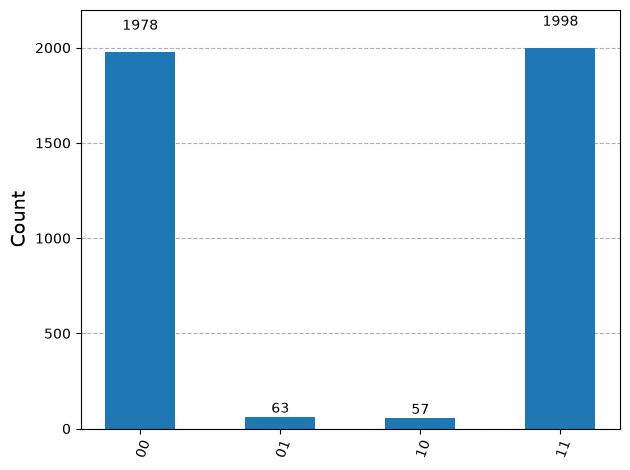

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

fake_backend = FakeManilaV2()
noisy_sim = AerSimulator.from_backend(fake_backend)   # simulator WITH realistic noise

bell = QuantumCircuit(2, 2)
bell.h(0); bell.cx(0, 1); bell.measure([0, 1], [0, 1])

isa = transpile(bell, noisy_sim)
counts_noisy = noisy_sim.run(isa, shots=4096).result().get_counts()
print(counts_noisy)
plot_histogram(counts_noisy)

## 10b · Running on a real IBM QPU  *(optional, requires an account)*
1. Free account at **quantum.ibm.com** (the new IBM Quantum Platform, on IBM Cloud) with an instance on the **Open plan**.
2. Create your **API key** (44 characters). *Optional:* copy your instance's **CRN**.
3. In Colab ▸ **Secrets** (key icon), create `IBM_QUANTUM_TOKEN` with the API key (and optionally `IBM_INSTANCE_CRN`).

> As of 2025 the correct channel is `channel='ibm_quantum_platform'` (no longer `ibm_quantum`).

In [ ]:
try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
    from google.colab import userdata

    token = userdata.get('IBM_QUANTUM_TOKEN')
    try:
        instance = userdata.get('IBM_INSTANCE_CRN')
    except Exception:
        instance = None

    service = QiskitRuntimeService(channel='ibm_quantum_platform', token=token, instance=instance)
    backend = service.least_busy(operational=True, simulator=False)
    print('Running on:', backend.name)

    circ = QuantumCircuit(2); circ.h(0); circ.cx(0, 1); circ.measure_all()
    pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
    isa = pm.run(circ)

    job = SamplerV2(backend).run([isa], shots=1024)
    print('Job id:', job.job_id())
    counts_hardware = job.result()[0].data.meas.get_counts()
    print(counts_hardware)
    plot_histogram(counts_hardware)
except Exception as e:
    print('Did not run on real hardware:', type(e).__name__, '-', e)
    print('No problem: section 10 (simulated noise) does not require an account.')

Did not run on real hardware: ModuleNotFoundError - No module named 'google'
No problem: section 10 (simulated noise) does not require an account.


# 11 · Comparison: ideal vs. noisy vs. real hardware
Let's put the three histograms side by side to *see* decoherence. As the real-hardware example we use counts obtained during the workshop on `ibm_kingston`. **Replace them with your own** if you ran section 10b.

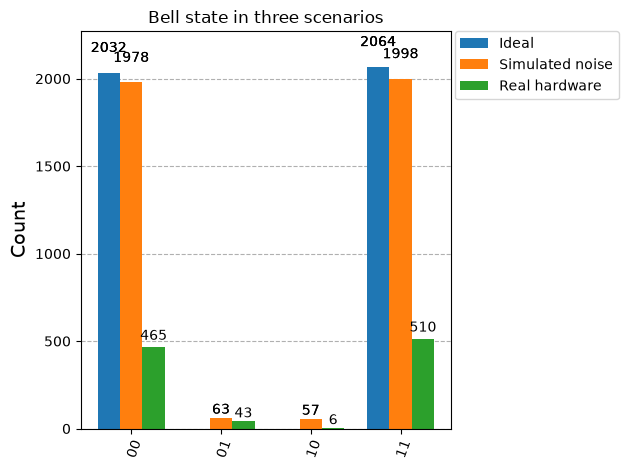

In [ ]:
# 1) Ideal
bell = QuantumCircuit(2, 2); bell.h(0); bell.cx(0,1); bell.measure([0,1],[0,1])
ideal = sim.run(bell, shots=4096).result().get_counts()

# 2) Simulated noise (from section 10)
noisy = counts_noisy

# 3) Real hardware: paste your own counts here (workshop example on ibm_kingston)
hardware = {'00': 465, '11': 510, '01': 43, '10': 6}

plot_histogram([ideal, noisy, hardware],
               legend=['Ideal', 'Simulated noise', 'Real hardware'],
               title='Bell state in three scenarios')

In [ ]:
# Error rate = fraction of "forbidden" outcomes (01 and 10)
forbidden = hardware.get('01', 0) + hardware.get('10', 0)
total = sum(hardware.values())
print(f'Forbidden outcomes: {forbidden} out of {total}')
print(f'Approx. error rate:  {100*forbidden/total:.1f}%')

Forbidden outcomes: 49 out of 1024
Approx. error rate:  4.8%


In an ideal world, `01` and `10` would both be **zero**. That small percentage is, measured live, the **decoherence** the slides talk about — and the reason quantum error correction exists.